<a href="https://colab.research.google.com/github/arushnab/Genrify/blob/main/notebooks/Lyrics_Based_Music_Genre_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import nbformat
import json

path = "/content/drive/MyDrive/Colab Notebooks/Lyrics-Based Music Genre Classification.ipynb"

# Load as raw JSON and strip widgets directly
with open(path, "r", encoding="utf-8") as f:
    nb_json = json.load(f)

nb_json.get("metadata", {}).pop("widgets", None)

with open(path, "w", encoding="utf-8") as f:
    json.dump(nb_json, f, indent=1)

print("Done — widgets metadata removed")

#Data Loading

###Load Dataset

In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/APS360_Project/archive/songs.csv')
print(df.columns.tolist())
print(df.shape)
print(df['genre'].value_counts())

Mounted at /content/drive
['id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics', 'year', 'genre', 'popularity', 'total_artist_followers', 'avg_artist_popularity', 'artist_ids', 'niche_genres']
(550622, 24)
genre
Rock          197168
Pop            72539
Electronic     69755
Folk           50843
Country        46076
Hip-Hop        41745
R&B            27337
Jazz           17010
Blues          15976
Classical      12173
Name: count, dtype: int64


##Modify Dataframe and Balance Classes

In [ ]:
import pandas as pd

# Keeping only necessary columns
df = df[['name', 'artists', 'lyrics', 'genre']]

# Drop all songs with missing or very short lyrics (less than 100 characters)
df = df.dropna(subset=['lyrics'])
df = df[df['lyrics'].str.len() >= 100]

# Lowercase and normalize whitespace
df['lyrics'] = df['lyrics'].str.lower().str.replace(r'\s+', ' ', regex=True).str.strip()

# Balance datafram to 5000 samples per genre
df_balanced = (
    df.groupby('genre')
    .apply(lambda x: x.sample(n=min(len(x), 5000), random_state=42))
    .reset_index(drop=True)
)

print(df_balanced['genre'].value_counts())
print(df_balanced.shape)

genre
Blues         5000
Classical     5000
Country       5000
Electronic    5000
Folk          5000
Hip-Hop       5000
Jazz          5000
Pop           5000
R&B           5000
Rock          5000
Name: count, dtype: int64
(50000, 4)


/tmp/ipykernel_4046/484909941.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), 5000), random_state=42))


## Build Train/Test/Val Split

Train: 34471, Val: 7732, Test: 7797


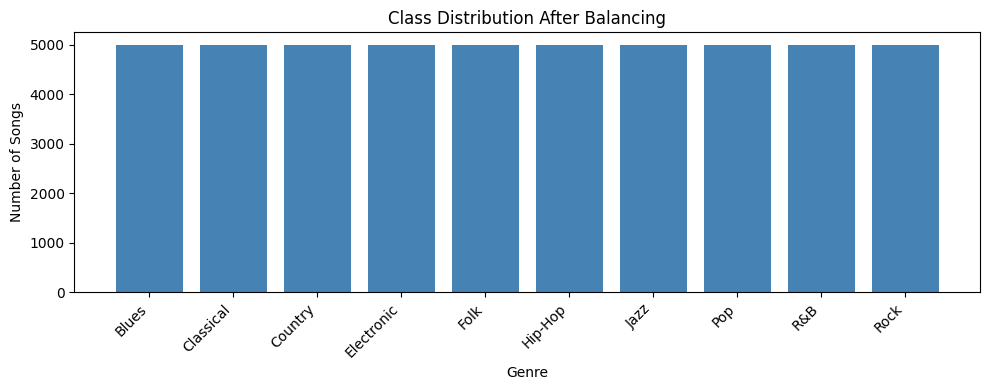

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Get unique artists and split them
artists = df_balanced['artists'].unique()
artists_train, artists_temp = train_test_split(artists, test_size=0.30, random_state=42)
artists_val, artists_test = train_test_split(artists_temp, test_size=0.50, random_state=42)

# Assign splits based on artist
train_df = df_balanced[df_balanced['artists'].isin(artists_train)].reset_index(drop=True)
val_df   = df_balanced[df_balanced['artists'].isin(artists_val)].reset_index(drop=True)
test_df  = df_balanced[df_balanced['artists'].isin(artists_test)].reset_index(drop=True)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Plot class distribution
fig, ax = plt.subplots(figsize=(10, 4))
genre_counts = df_balanced['genre'].value_counts().sort_index()
ax.bar(genre_counts.index, genre_counts.values, color='steelblue')
ax.set_xlabel('Genre')
ax.set_ylabel('Number of Songs')
ax.set_title('Class Distribution After Balancing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

In [ ]:
# Example of cleaned lyrics from each split
example = train_df.groupby('genre').first()[['name', 'artists', 'lyrics']].reset_index()

for _, row in example.iterrows():
    print(f"Genre: {row['genre']}")
    print(f"Song: {row['name']} by {row['artists']}")
    print(f"Lyrics (first 200 chars): {row['lyrics'][:200]}")
    print("-" * 60)

Genre: Blues
Song: Layla by ["Derek & The Dominos"]
Lyrics (first 200 chars): what'll you do when you get lonely and nobody's waiting by your side? you've been running and hiding much too long you know it's just your foolish pride layla you've got me on my knees layla i'm beggi
------------------------------------------------------------
Genre: Classical
Song: Chip on My Shoulder by ["Christian Borle", "'Legally Blonde' Greek Chorus", "Laura Bell Bundy", "'Legally Blonde' Ensemble"]
Lyrics (first 200 chars): whoa, elle? what's up, doc? love (excuse me?) i put my faith in love i followed where it led (love led you here?) to my personal circle of hell it has not worked out well i wish that i were dead 'caus
------------------------------------------------------------
Genre: Country
Song: la - ballerini album version by ["Kelsea Ballerini"]
Lyrics (first 200 chars): i've got a love and hate relationship with l.a. off the plane, paint my face in the car, park my heart at the valet i watch 

#Baseline Model - Logistic Regression

Validation Accuracy: 0.4448


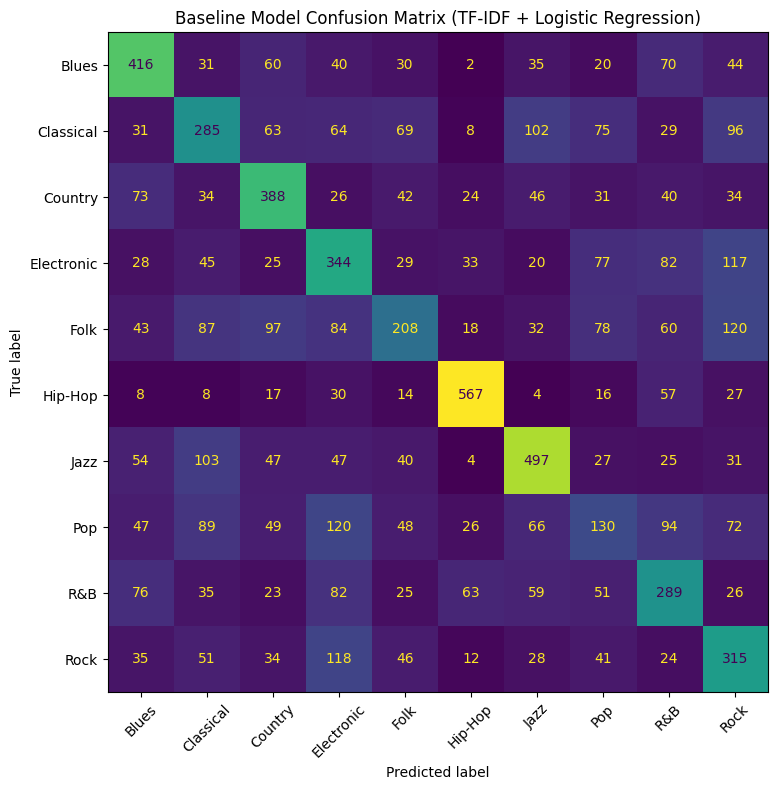

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# TF-IDF to convert each lyric into a vector of numbers
vectorizer = TfidfVectorizer(max_features=10000)
X_train = vectorizer.fit_transform(train_df['lyrics'])
X_val = vectorizer.transform(val_df['lyrics'])

y_train = train_df['genre']
y_val = val_df['genre']

# Train logistic regression
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

# Evaluate
val_preds = clf.predict(X_val)
acc = accuracy_score(y_val, val_preds)
print(f"Validation Accuracy: {acc:.4f}")

# Confusion matrix
genres = sorted(df_balanced['genre'].unique())
cm = confusion_matrix(y_val, val_preds, labels=genres)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=genres)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title('Baseline Model Confusion Matrix (TF-IDF + Logistic Regression)')
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
print(len(test_df))

7797


In [ ]:
# Save confusion matrix to Google Drive

import shutil
shutil.copy('baseline_confusion_matrix.png', '/content/drive/MyDrive/APS360_Project/baseline_confusion_matrix.png')

'/content/drive/MyDrive/APS360_Project/baseline_confusion_matrix.png'

#Primary Model

###Install and Load DistilBERT

In [ ]:
!pip install transformers -q

import torch
from transformers import DistilBertTokenizer, DistilBertModel
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Set up Dataset and Tokenizer

In [ ]:
from transformers import DistilBertTokenizer

# Label encoding
genres = sorted(df_balanced['genre'].unique())
genre2idx = {g: i for i, g in enumerate(genres)}
idx2genre = {i: g for g, i in genre2idx.items()}

print("Genre mapping:", genre2idx)

# Tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Dataset class
class LyricsDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=512):
        self.lyrics = df['lyrics'].tolist()
        self.labels = [genre2idx[g] for g in df['genre'].tolist()]
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.lyrics)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.lyrics[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create datasets and dataloaders
train_dataset = LyricsDataset(train_df, tokenizer)
val_dataset = LyricsDataset(val_df, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Genre mapping: {'Blues': 0, 'Classical': 1, 'Country': 2, 'Electronic': 3, 'Folk': 4, 'Hip-Hop': 5, 'Jazz': 6, 'Pop': 7, 'R&B': 8, 'Rock': 9}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches: 2155, Val batches: 484


## Define Model

In [ ]:
from transformers import DistilBertModel

class LyricsClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super(LyricsClassifier, self).__init__()
        self.distilbert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.classifier = nn.Sequential(
            nn.Linear(768, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        output = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = output.last_hidden_state[:, 0, :]  # CLS token
        return self.classifier(cls_output)

model = LyricsClassifier(num_classes=10).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model parameters: 66,890,506


## Training Loop

In [ ]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

criterion = nn.CrossEntropyLoss()
train_losses = []
val_losses = []
val_accuracies = []

EPOCHS = 10
best_val_loss = float('inf')
patience_counter = 0
PATIENCE = 3

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

# Freeze DistilBERT, train classifier head only
for param in model.distilbert.parameters():
    param.requires_grad = False

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                  lr=2e-5, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(optimizer,
                                            num_warmup_steps=warmup_steps,
                                            num_training_steps=total_steps)

print("=== Phase 1: Frozen DistilBERT (1 epoch) ===")
model.train()
total_loss = 0
for batch in train_loader:
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['label'].to(device)
    optimizer.zero_grad()
    outputs = model(input_ids, attention_mask)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    scheduler.step()
    total_loss += loss.item()
avg_train_loss = total_loss / len(train_loader)
train_losses.append(avg_train_loss)

model.eval()
total_val_loss = 0
correct = 0
total = 0
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        total_val_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
avg_val_loss = total_val_loss / len(val_loader)
val_losses.append(avg_val_loss)
val_accuracies.append(correct / total)
print(f"Epoch 1/10 | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {correct/total:.4f}")

# Unfreeze DistilBERT, fine-tune everything
for param in model.distilbert.parameters():
    param.requires_grad = True

optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(optimizer,
                                            num_warmup_steps=warmup_steps,
                                            num_training_steps=total_steps)

print("=== Phase 2: Unfrozen DistilBERT (up to 9 epochs) ===")
for epoch in range(2, EPOCHS + 1):
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    total_val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_accuracies.append(correct / total)
    print(f"Epoch {epoch}/10 | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {correct/total:.4f}")

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), '/content/drive/MyDrive/APS360_Project/best_model.pt')
        print(f"  --> Best model saved")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  --> Early stopping at epoch {epoch}")
            break

=== Phase 1: Frozen DistilBERT (1 epoch) ===
Epoch 1/10 | Train Loss: 2.2626 | Val Loss: 2.1076 | Val Acc: 0.2913
=== Phase 2: Unfrozen DistilBERT (up to 9 epochs) ===
Epoch 2/10 | Train Loss: 1.8217 | Val Loss: 1.5906 | Val Acc: 0.4644
  --> Best model saved
Epoch 3/10 | Train Loss: 1.5053 | Val Loss: 1.4779 | Val Acc: 0.5021
  --> Best model saved
Epoch 4/10 | Train Loss: 1.2493 | Val Loss: 1.5382 | Val Acc: 0.5010
Epoch 5/10 | Train Loss: 0.9822 | Val Loss: 1.6125 | Val Acc: 0.4915
Epoch 6/10 | Train Loss: 0.7405 | Val Loss: 1.8058 | Val Acc: 0.4784
  --> Early stopping at epoch 6


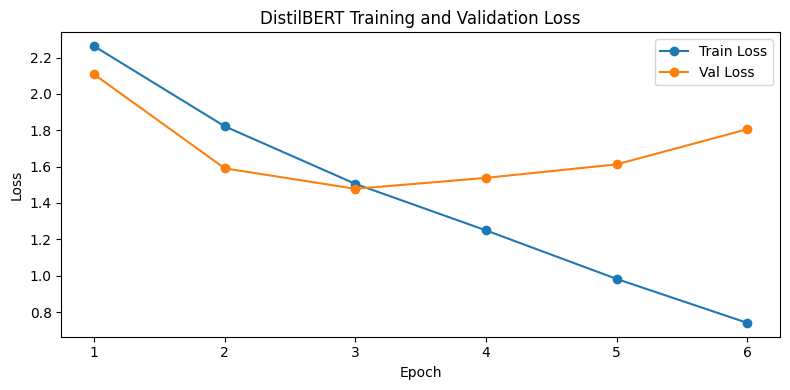

Song                                     True         Predicted    Correct
---------------------------------------------------------------------------
Please Love Me                           Blues        Blues        ✓
Summertime                               Classical    Jazz         ✗
People Are Crazy                         Country      Country      ✓
Prometheus                               Electronic   Electronic   ✓
Where I Stand                            Folk         Electronic   ✗
See How                                  Hip-Hop      Electronic   ✗
Toot, Toot, Tootsie, Goodbye             Jazz         Jazz         ✓
Busted Up                                Pop          R&B          ✗
Young Love                               R&B          R&B          ✓
In der Palästra                          Rock         Rock         ✓


In [ ]:
# Plot loss curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss', marker='o')
ax.plot(range(1, len(val_losses) + 1), val_losses, label='Val Loss', marker='o')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('DistilBERT Training and Validation Loss')
ax.legend()
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()

# Example predictions
model.eval()
examples = val_df.groupby('genre').first().reset_index()
print(f"{'Song':<40} {'True':<12} {'Predicted':<12} {'Correct'}")
print("-" * 75)
with torch.no_grad():
    for _, row in examples.iterrows():
        enc = tokenizer(row['lyrics'], max_length=512, padding='max_length',
                        truncation=True, return_tensors='pt')
        input_ids = enc['input_ids'].to(device)
        attention_mask = enc['attention_mask'].to(device)
        output = model(input_ids, attention_mask)
        probs = torch.softmax(output, dim=1)
        pred_idx = torch.argmax(probs).item()
        pred_genre = idx2genre[pred_idx]
        correct = "✓" if pred_genre == row['genre'] else "✗"
        print(f"{row['name'][:38]:<40} {row['genre']:<12} {pred_genre:<12} {correct}")

In [ ]:
import shutil
shutil.copy('loss_curve.png', '/content/drive/MyDrive/APS360_Project/loss_curve.png')
shutil.copy('baseline_confusion_matrix.png', '/content/drive/MyDrive/APS360_Project/baseline_confusion_matrix.png')
shutil.copy('class_distribution.png', '/content/drive/MyDrive/APS360_Project/class_distribution.png')

'/content/drive/MyDrive/APS360_Project/class_distribution.png'

In [ ]:
# Load best model
model.load_state_dict(torch.load('/content/drive/MyDrive/APS360_Project/best_model.pt'))
model.eval()

# Create test dataloader
test_dataset = LyricsDataset(test_df, tokenizer)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Evaluate on test set
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        outputs = model(input_ids, attention_mask)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = correct / total
print(f"Test Accuracy: {test_acc:.4f}")

# Per-class breakdown
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds, target_names=genres))

Test Accuracy: 0.4911
              precision    recall  f1-score   support

       Blues       0.49      0.57      0.53       810
   Classical       0.49      0.44      0.46       713
     Country       0.48      0.57      0.52       873
  Electronic       0.56      0.39      0.46       724
        Folk       0.30      0.29      0.30       706
     Hip-Hop       0.75      0.81      0.78       753
        Jazz       0.54      0.48      0.51       890
         Pop       0.31      0.27      0.29       754
         R&B       0.46      0.60      0.52       819
        Rock       0.49      0.46      0.48       755

    accuracy                           0.49      7797
   macro avg       0.49      0.49      0.48      7797
weighted avg       0.49      0.49      0.49      7797

